# Домашнее задание №2
### Третьякова Юля Б06-303

### Часть 1

Я выбрала белок гемоглобин beta (HBB) для множественного выравнивания.

Виды:
- Homo sapiens — человек
- Mus musculus — мышь
- Bos taurus — корова
- Gallus gallus — курица

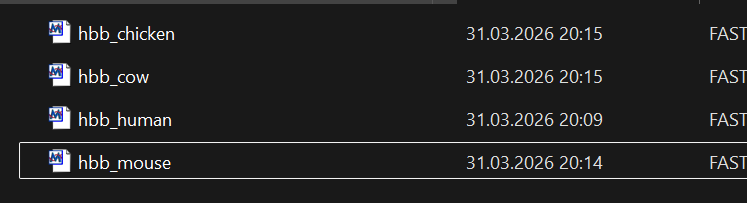

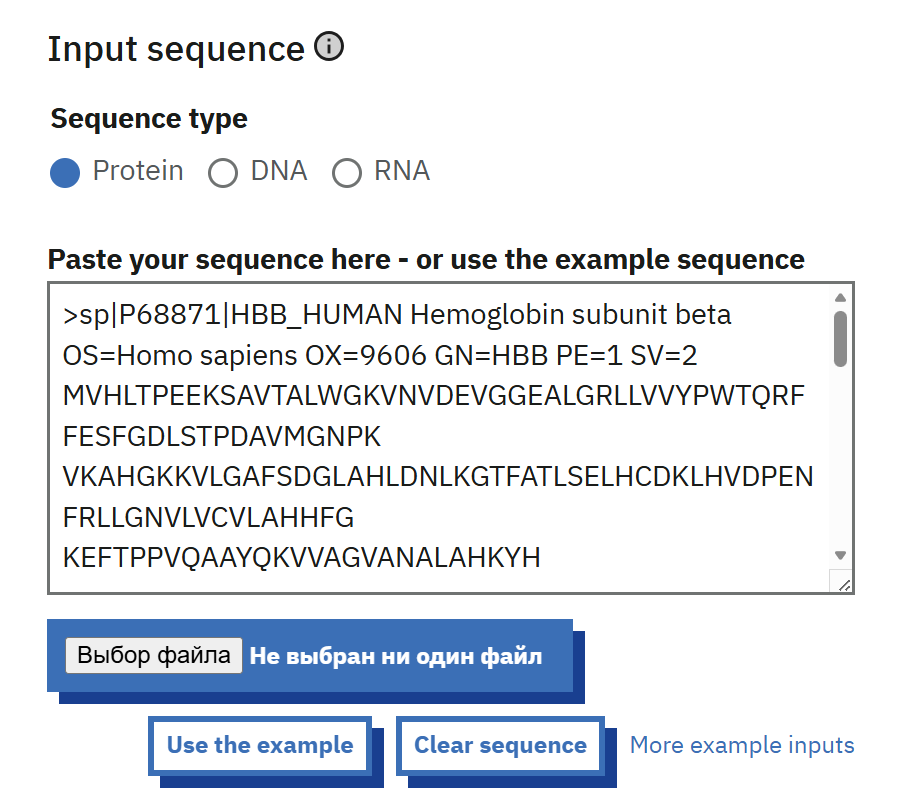

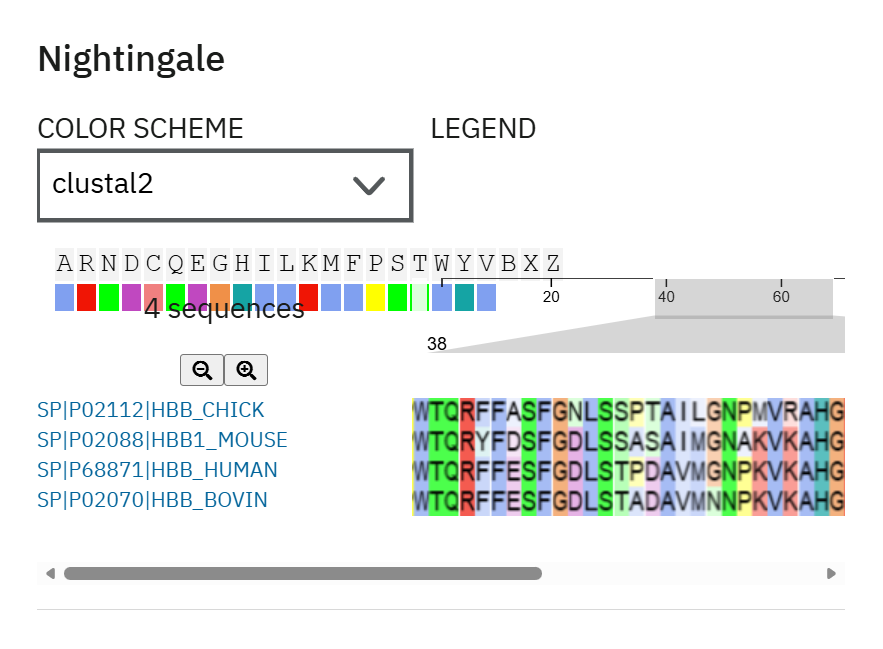

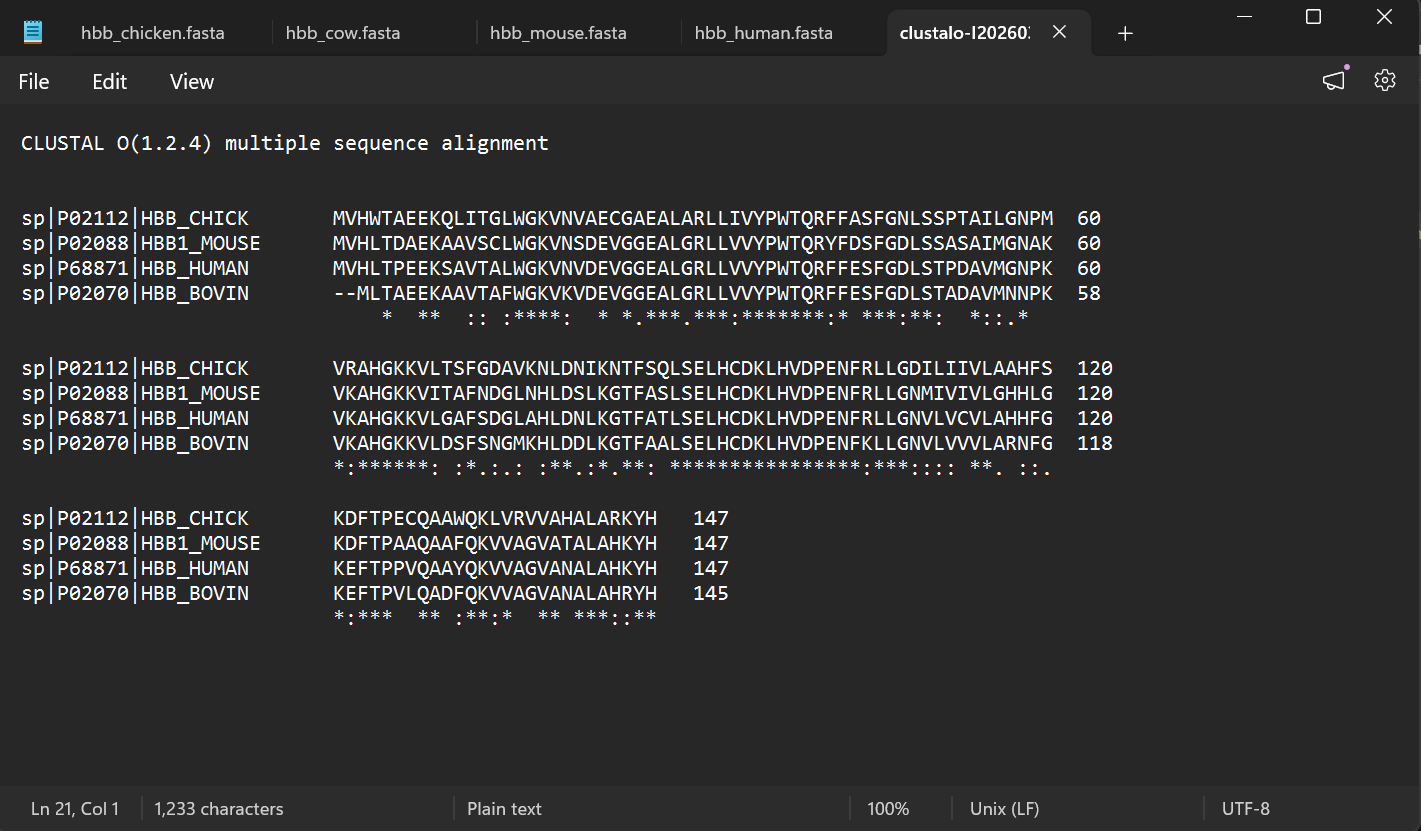

Из результатов выравнивания можно отметить:
- последовательности действительно гомологичны
- у beta-глобинов много консервативных позиций
- различия есть, но общая структура очень похожа
- коровья последовательность немного отличается по длине в начале, поэтому там стоят два гэпа

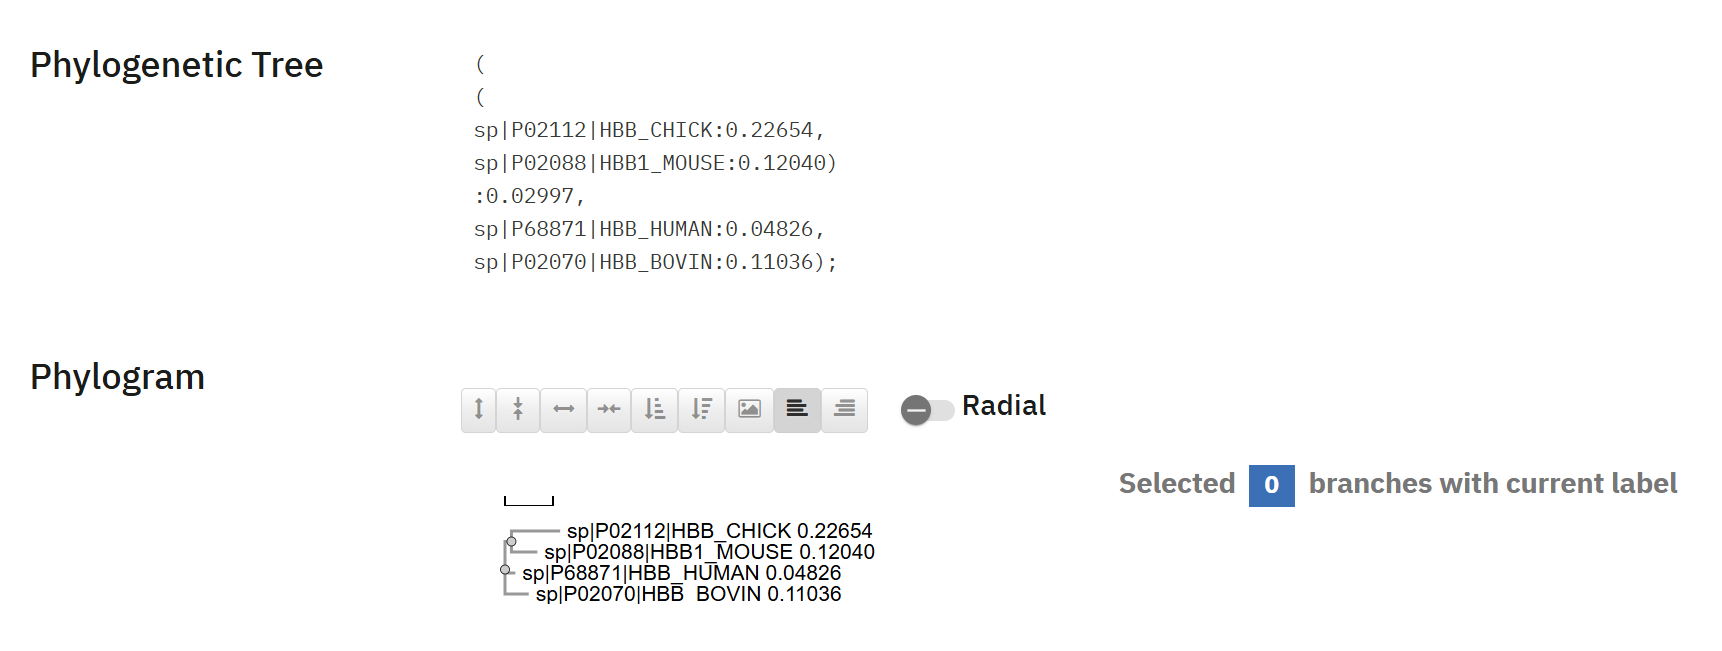

Ожидали: человек + корова как млекопитающие, мышь рядом с ними, курица более далёкая.

Clustal сгруппировал: курицу + мышь, а человек и корова стоят отдельно.

Из-за малого числа анализируемых последовательностей и использования одного короткого консервативного белка, не получилось построить дерево, которое бы отражало реальную филогению видов.

### Часть 2


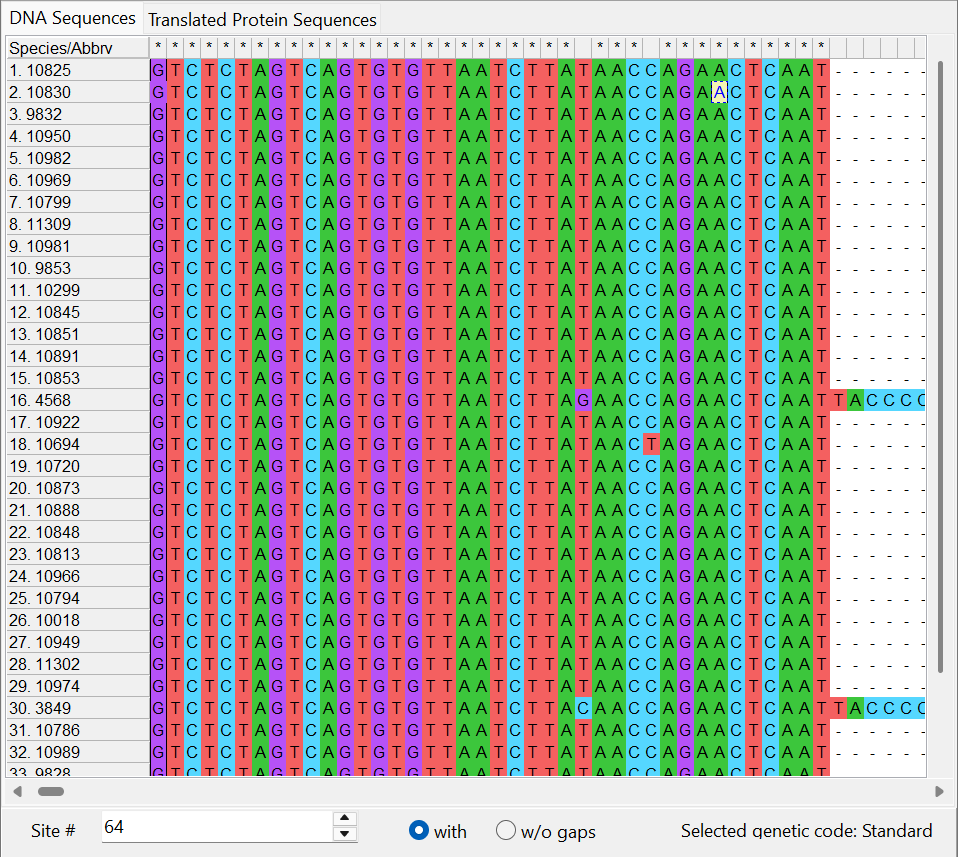

Множественное выравнивание последовательностей было выполнено в программе MEGA с помощью алгоритма MUSCLE.

После выравнивания видно, что последовательности в целом хорошо совпадают, различия встречаются только в отдельных позициях, а также местами появляются гэпы.

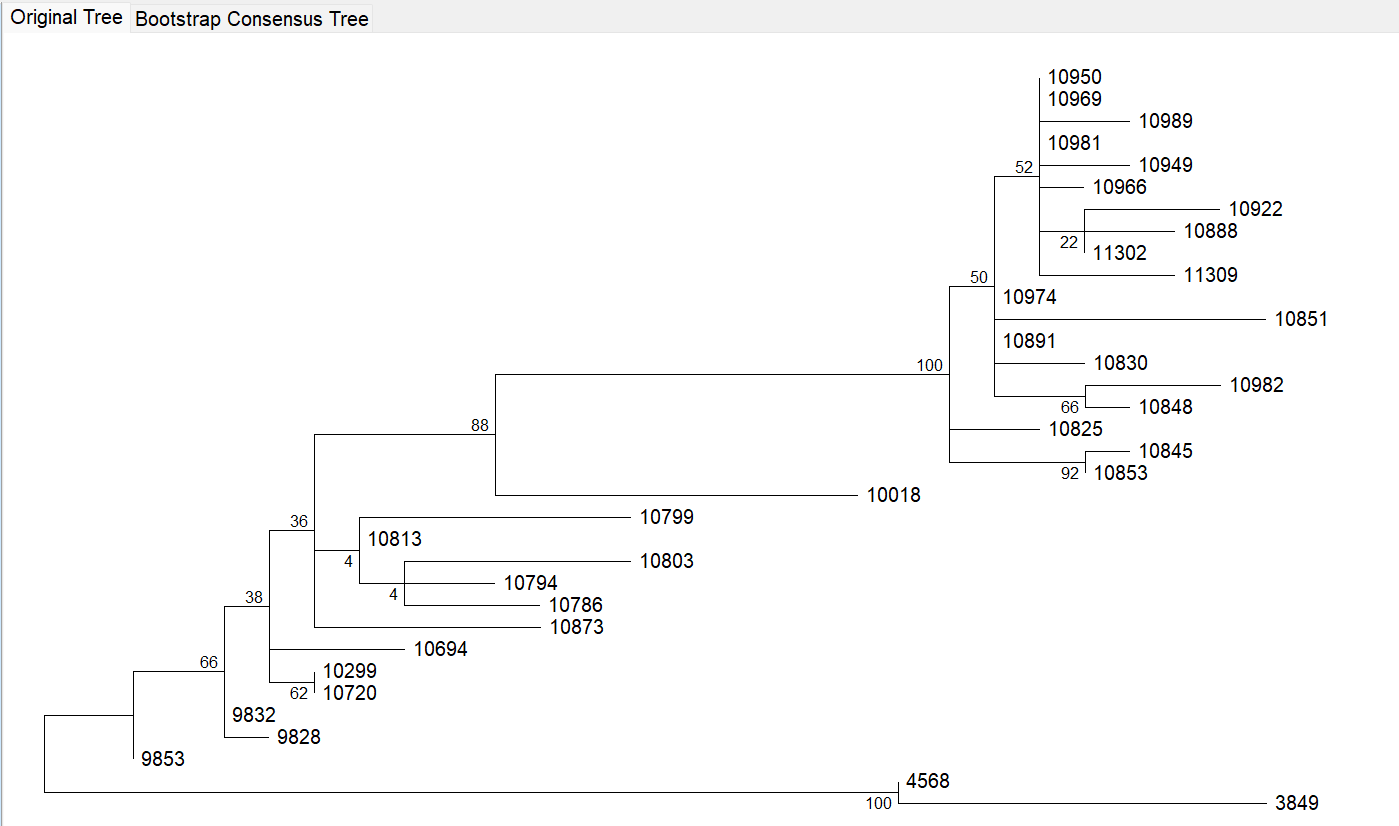

Построили филогенетическое дерево методом Maximum Likelihood.

По дереву видно:

- последовательности распадаются на несколько групп
- есть один большой кластер справа
- есть более удалённые последовательности слева;
3849 и 4568 образуют отдельную ветвь с высокой поддержкой (bootstrap-значение 100)
- часть узлов поддержана хорошо (88, 92, 100), а часть слабо (4, 22, 36, 38, 50, 52)

Теперь добавим ещё 3 последовательности из других штаммов ковида. В NCBI Virus я отфильтровала записи по странам: Австралия, Чили и Египет. Так как часто находились полные геномные записи, приходилось скачивать coding sequences и отдельно оставлять только последовательность S-гена. После этого новые последовательности были добавлены к исходному набору и выровнены в MEGA так же с помощью MUSCLE.

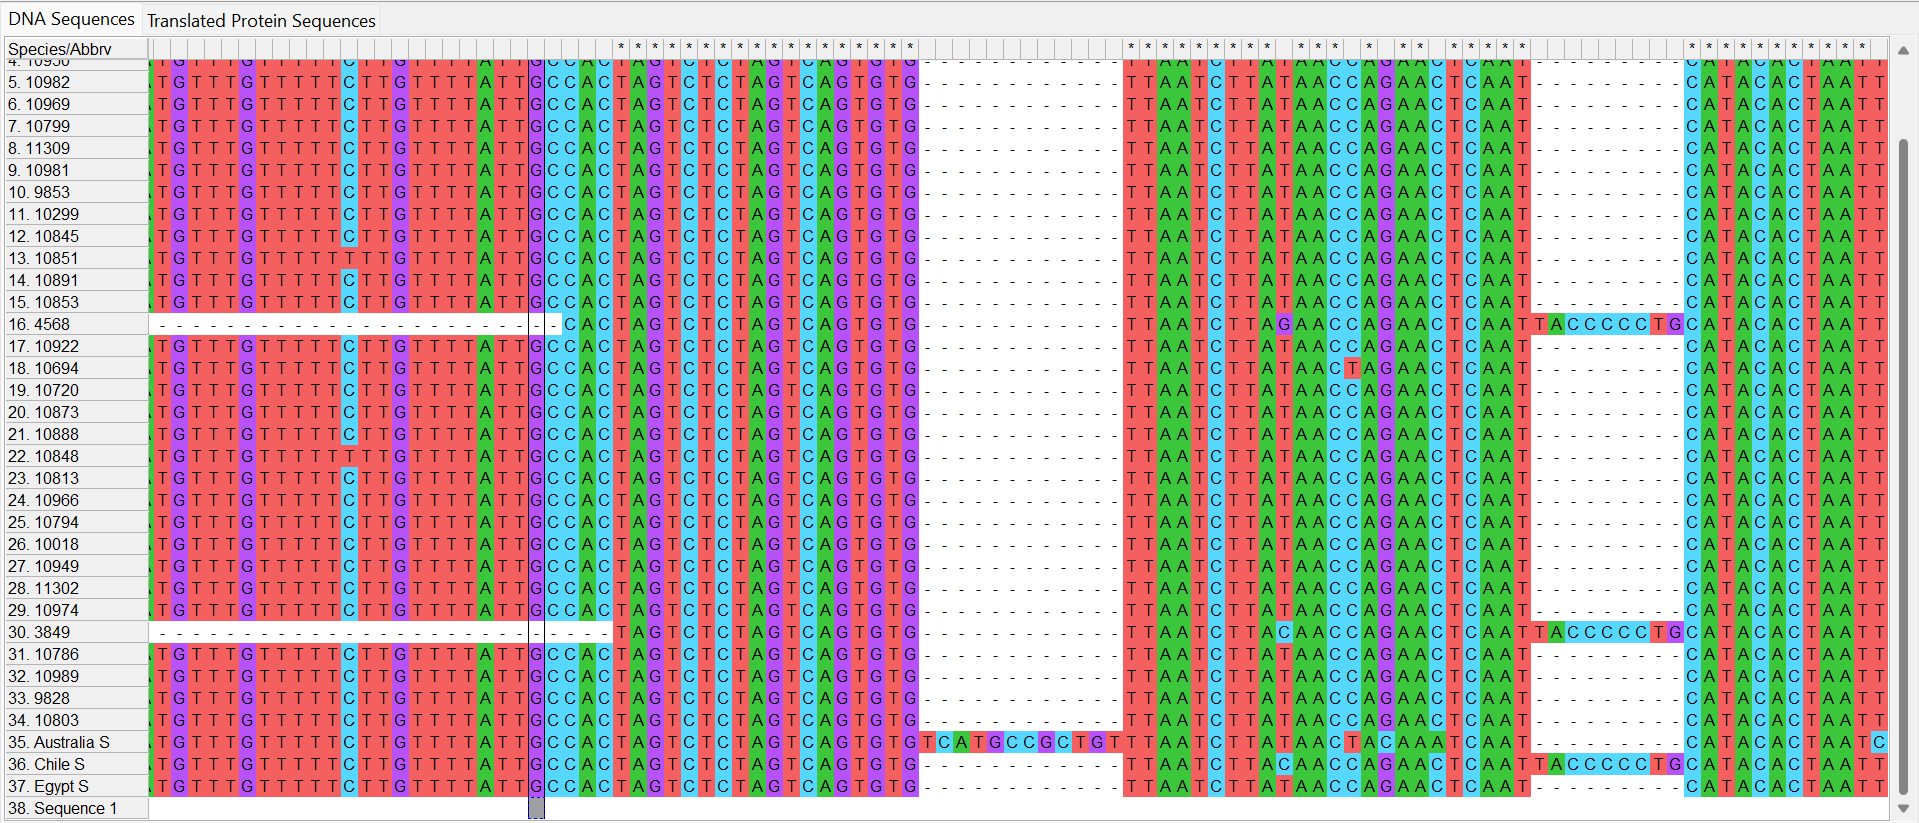

После добавления последовательностей из Австралии, Чили и Египта видно, что они не вошли в основной большой кластер, а ушли в отдельную ветвь. При этом Australia_S отделяется гораздо раньше остальных (по сути - изначально отдельная ветка), а Chile_S оказывается близко к последовательностям 3849 и 4568. Egypt_S тоже относится к этой же удалённой группе, но присоединяется к ней на более высоком уровне.

Такой результат может быть вполне правдивым: Австралия стоит отдельно из-за своей географической удалённости. А Египет и Чили могли оказаться в одной ветви с вариантами вируса из России из-за международных контактов (туристы и тд).

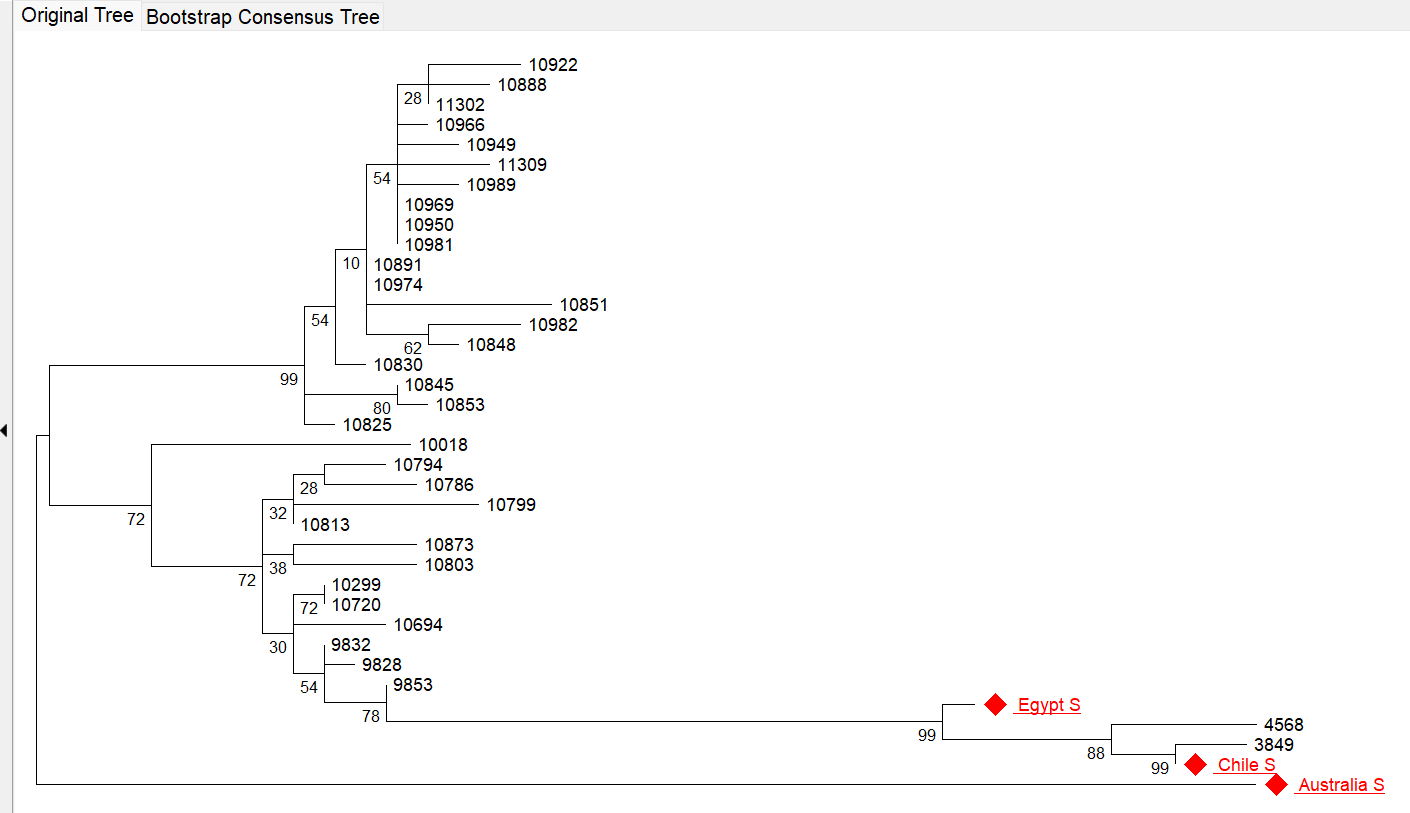

### Часть 3

#### 3.1) Неизвестный белок

Поскольку запрос уже белковый, выберем здесь blastp по базе nr. Потому что nr — большая белковая база, а мы хотим сначала просто понять, на что это вообще похоже, без узкого ограничения.

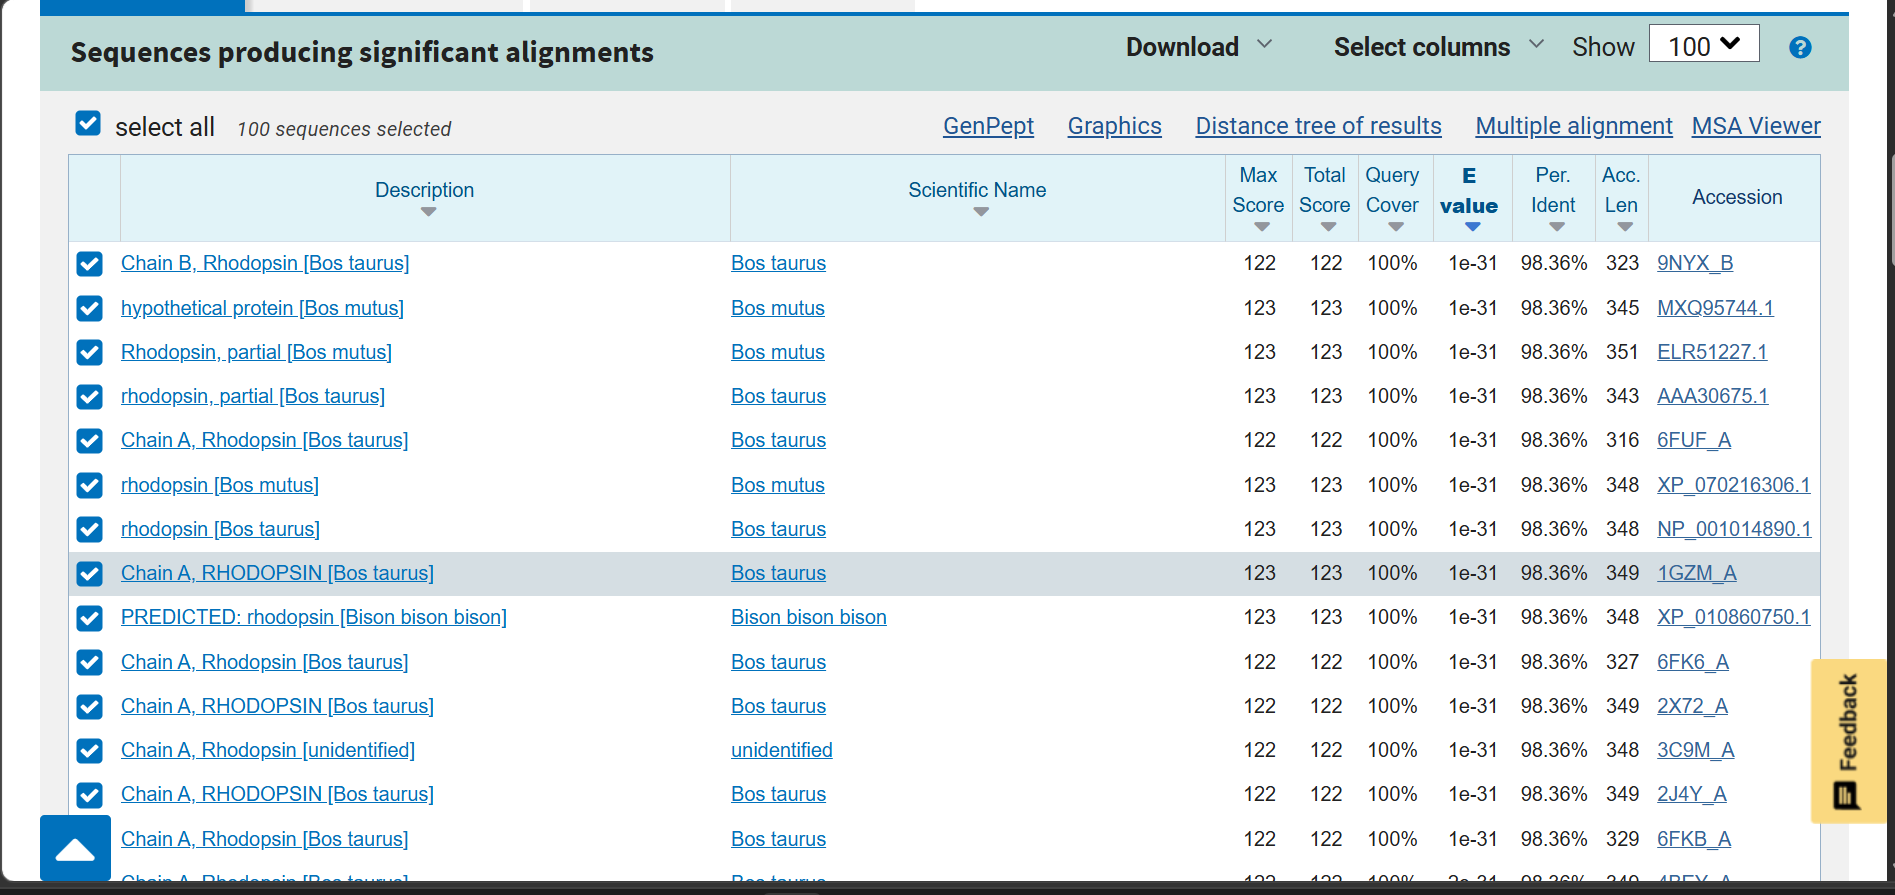

Видим значения: Query cover = 100%, Per. Ident = 98.36%, E-value = 1e-31.

Для такого короткого белка это фактически однозначная идентификация, поэтому можно с уверенностью сказать, что это **родопсин** — светочувствительный мембранный белок фоторецепторов сетчатки.

Поскольку дана аминокислотная последовательность и требуется проверить наличие человеческого ортолога, целесообразно использовать blastp по RefSeq proteins - чище и компактнее, чем nr, там меньше дублей и мусорных записей. Ещё указываем организм - Homo sapiens.

tblastn понадобился бы, если бы запрос был белком, а искать надо было в нуклеотидной базе (например, белок предсказан неточно/не до конца).

Наш поиск сразу сравнивает белок с уже аннотированными человеческими белками и позволяет проще интерпретировать гомологию.

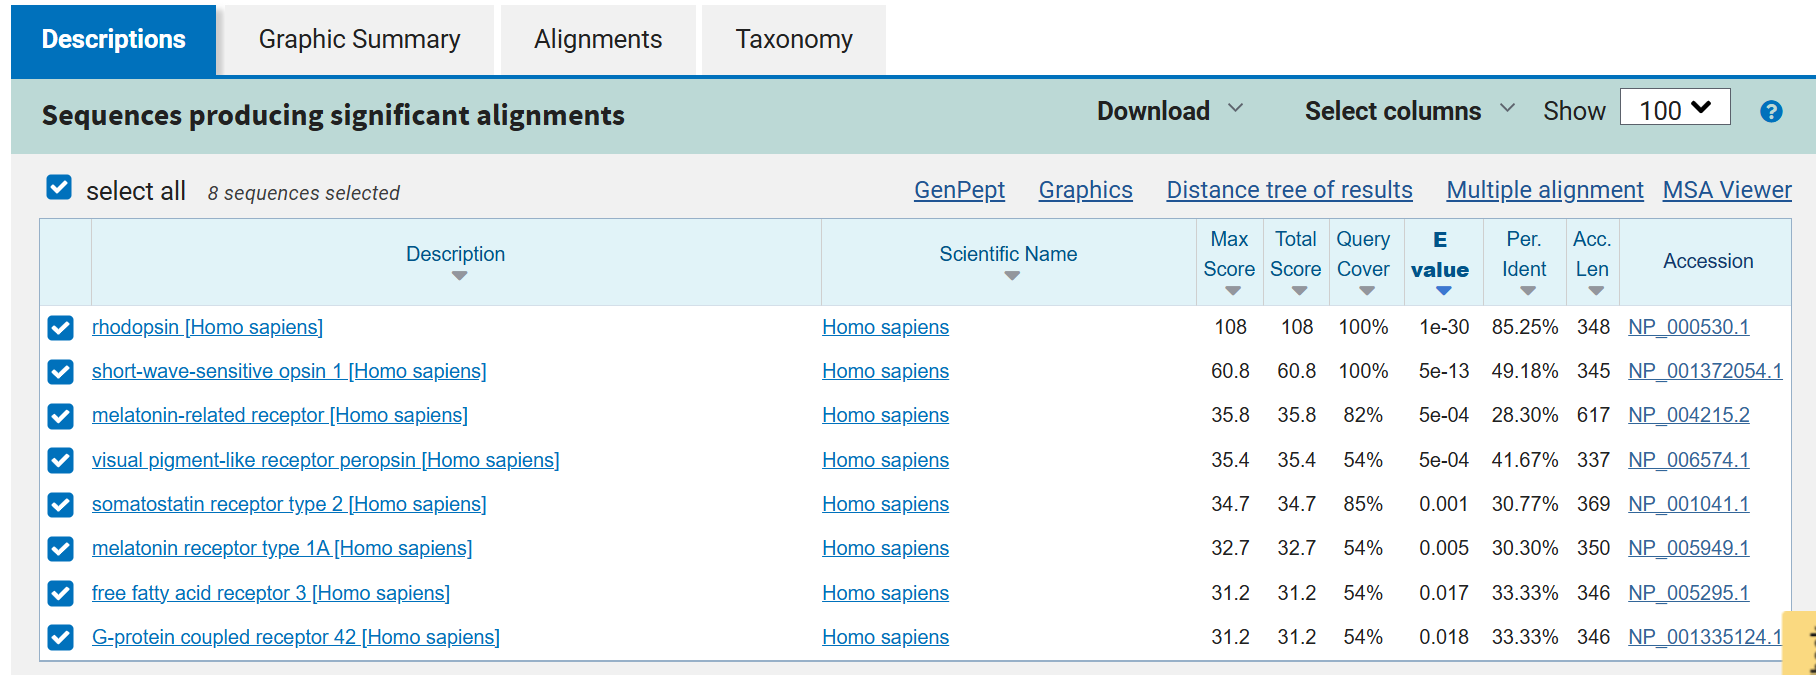

Наиболее похожий на исходный белок у человека — родопсин (rhodopsin, ген RHO). Его показатели: 100% покрытие запроса, 85.25% идентичности, E-value = 1e-30. Следовательно, исходная последовательность соответствует фрагменту белка родопсина.

У человека мутации в гене RHO связаны с заболеваниями сетчатки, прежде всего с пигментным ретинитом, а также с некоторыми формами врождённой ночной слепоты.

#### 3.2) Люцифераза

Для поиска 10 лучших кандидатов на люциферазу в наборе последовательностей Photinus pyralis была использована белковая последовательность люциферазы Nipponoluciola cruciata (BAE80731.1).

Для Photinus pyralis найденный файл содержал уже предсказанные белковые последовательности, а не нуклеотидные транскрипты. Поэтому этап перевода транскриптов в белки с помощью TransDecoder.LongOrfs не потребовался.
Из файла photinus.fasta была создана локальная белковая BLAST-база командой:

`makeblastdb -in photinus.fasta -dbtype prot`

Затем был выполнен поиск с помощью:

`blastp -db photinus.fasta -query lcruciata.fasta -outfmt 6 > photinus_hits.txt`

Из результатов были выбраны 10 лучших уникальных non-PDB хитов:

AB076905.1, ACH53166.1, BAE33044.1, BAE33661.1, ABM67533.1, ABM67534.1, ABM67535.1, YAU67282.1, YCY47466.1, SNT66991.1.

Их последовательности были сохранены в отдельный FASTA-файл с помощью команды:

`seqtk subseq photinus.fasta top10_ids_clean.txt > top10_luciferase_candidates.fasta`



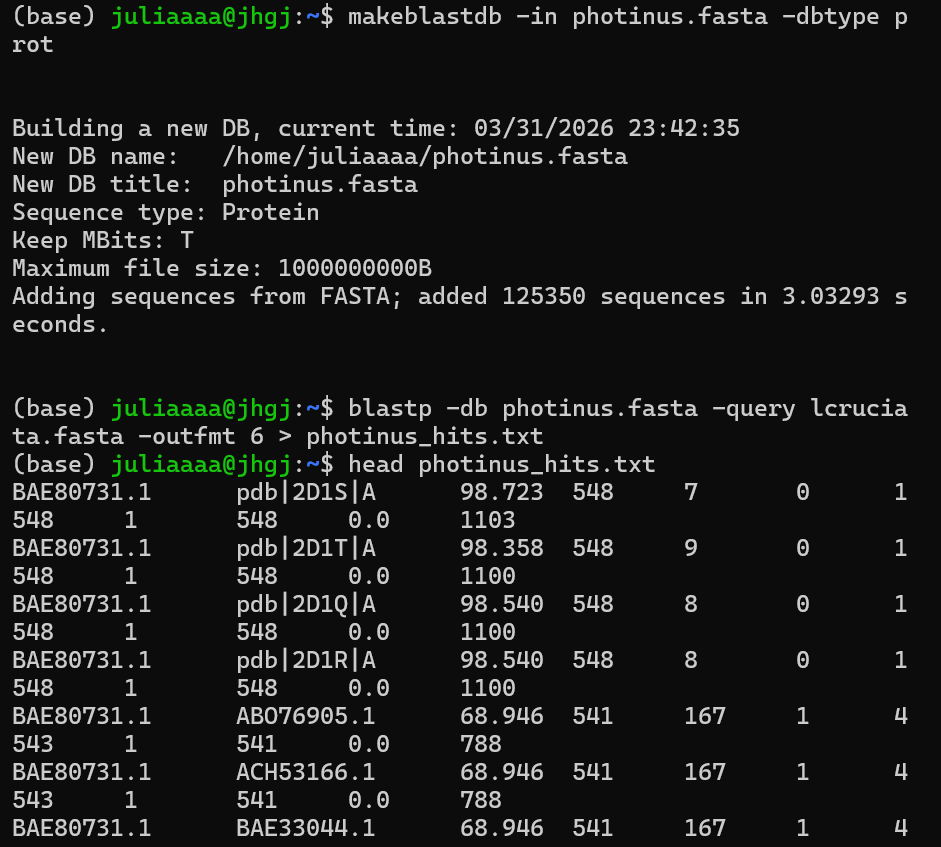

При первичном отборе лучших хитов среди первых результатов BLAST присутствовали записи формата PDB (структурные записи белков, например pdb|...). Поскольку целью задания было получить кандидатов именно из набора последовательностей Photinus pyralis, а не структурные записи из базы PDB, первые 4 таких хита были исключены из рассмотрения. После этого для итогового списка были выбраны 10 лучших уникальных non-PDB последовательностей.

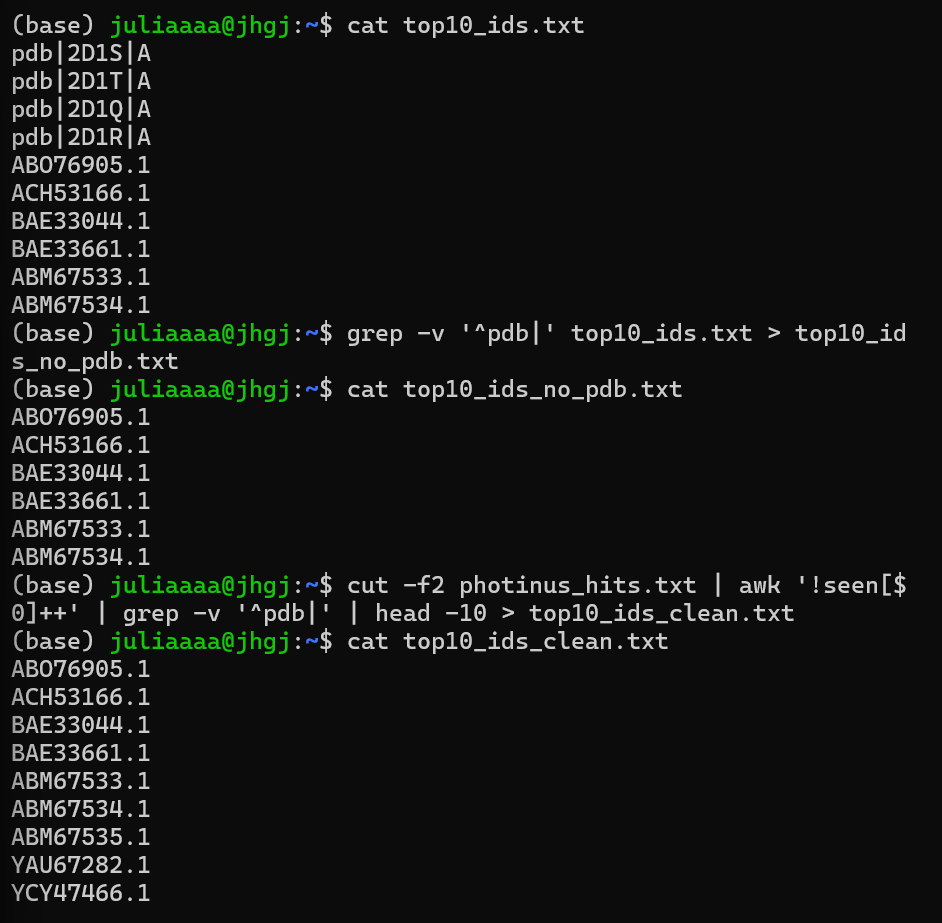

Прилагаю скрин готового fasta файла, он так же будет загружен на гитхаб.

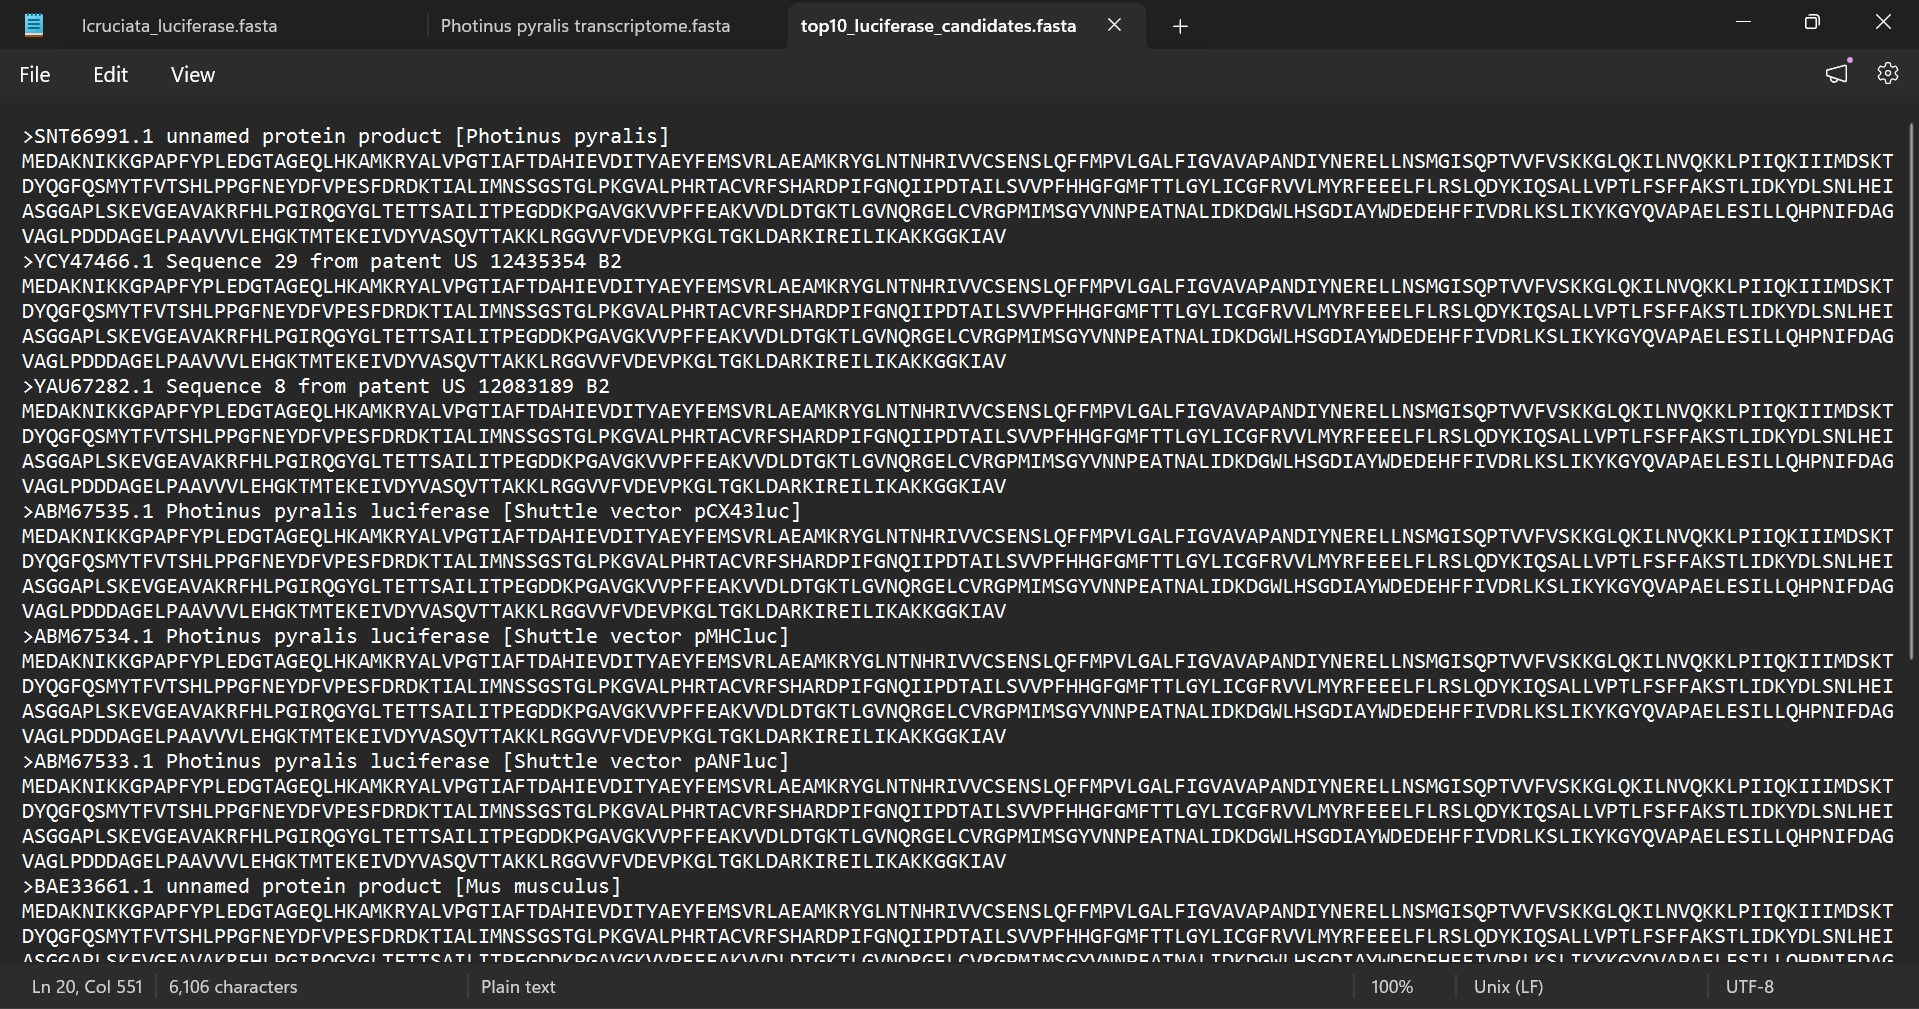